# 02 -- ArcFace for CEDAR Signature Verification

ArcFace replaces pair/triplet sampling with a **classification objective + angular margin**.
Each writer is a class; at inference, cosine similarity between L2-normalised embeddings is used.

**v2 fixes (v1 showed embedding collapse):**
- Backbone: SmallCNN -> ResNet18Embed (too shallow for signatures)
- Margin: 0.5 -> 0.3 (0.5 is for millions of face classes; CEDAR has 38)
- Added training augmentation (affine + noise)
- Scheduler: StepLR -> CosineAnnealingLR


---
## Section 0 -- Setup

In [1]:
import sys
import re
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

from sklearn import metrics as sk_metrics
from sklearn.decomposition import PCA

def _find_project_root(start):
    for p in [start] + list(start.parents):
        if (p / '.git').exists() or (p / 'requirements.txt').exists():
            return p
    raise RuntimeError(f'Cannot find project root from {start}')

PROJECT_ROOT = _find_project_root(Path().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.seed import set_seed
from src.models.backbones import ResNet18Embed
from src.metrics.verification import compute_metrics

SEED = 42
set_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device      :', DEVICE)
print('Project root:', PROJECT_ROOT)


Device      : cuda
Project root: /home/jovyan/vault


---
## Section 1 -- Load CEDAR

In [2]:
DATA_ROOT = PROJECT_ROOT / 'datasets' / 'CEDAR'
ORG_DIR   = DATA_ROOT / 'full_org'
FORG_DIR  = DATA_ROOT / 'full_forg'
assert ORG_DIR.exists() and FORG_DIR.exists(), f'CEDAR not found at {DATA_ROOT}'

PAT_ORG  = re.compile(r'^original_(\d+)_(\d+)\.png$',  re.IGNORECASE)
PAT_FORG = re.compile(r'^forgeries_(\d+)_(\d+)\.png$', re.IGNORECASE)

rows = []
for fp in ORG_DIR.iterdir():
    m = PAT_ORG.match(fp.name)
    if m:
        rows.append({'path': str(fp), 'writer_id': int(m.group(1)),
                     'sample_id': int(m.group(2)), 'label': 'genuine'})
for fp in FORG_DIR.iterdir():
    m = PAT_FORG.match(fp.name)
    if m:
        rows.append({'path': str(fp), 'writer_id': int(m.group(1)),
                     'sample_id': int(m.group(2)), 'label': 'forgery'})

df = pd.DataFrame(rows).sort_values(['writer_id','label','sample_id']).reset_index(drop=True)
print(f'Total: {len(df)}  |  writers: {df["writer_id"].nunique()}')
print(df['label'].value_counts().to_string())


Total: 2640  |  writers: 55
label
forgery    1320
genuine    1320


---
## Section 2 -- Writer-level Split

In [3]:
def split_writers(df, train=0.70, val=0.15, test=0.15, seed=42):
    writers = np.array(sorted(df['writer_id'].unique()))
    rng = np.random.default_rng(seed)
    rng.shuffle(writers)
    n = len(writers)
    n_train = int(round(n * train))
    n_val   = int(round(n * val))
    return set(writers[:n_train]), set(writers[n_train:n_train+n_val]), set(writers[n_train+n_val:])

train_writers, val_writers, test_writers = split_writers(df, seed=SEED)
sorted_train_writers = sorted(train_writers)
writer_to_class      = {wid: idx for idx, wid in enumerate(sorted_train_writers)}
NUM_CLASSES          = len(sorted_train_writers)

print(f'Train: {len(train_writers)} writers  |  Val: {len(val_writers)}  |  Test: {len(test_writers)}')
print(f'ArcFace num_classes: {NUM_CLASSES}')


Train: 38 writers  |  Val: 8  |  Test: 9
ArcFace num_classes: 38


---
## Section 3 -- Transforms and Datasets

Training uses augmentation to combat the small dataset (38 x 24 = 912 images).
Eval transform is deterministic (no augmentation).


In [4]:
IMG_SIZE = 224

# Training augmentation -- fill=255 keeps background white after affine
train_tfm = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomAffine(degrees=8, translate=(0.05, 0.05), scale=(0.93, 1.07), fill=255),
    T.ToTensor(),
    T.Normalize(mean=[0.5], std=[0.5]),
    T.Lambda(lambda x: x + 0.015 * torch.randn_like(x)),
])

# Eval: no augmentation
eval_tfm = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.5], std=[0.5]),
])


class SignatureClassDataset(Dataset):
    """Single-image dataset for ArcFace training: returns (image, class_idx)."""

    def __init__(self, df, writer_to_class, writer_set, label_filter='genuine', transform=None):
        sub = df[(df['writer_id'].isin(writer_set)) & (df['label'] == label_filter)]
        self.records   = sub[['path', 'writer_id']].reset_index(drop=True)
        self.w2c       = writer_to_class
        self.transform = transform

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        row = self.records.iloc[idx]
        img = Image.open(row['path']).convert('L')
        if self.transform:
            img = self.transform(img)
        return img, self.w2c[row['writer_id']]


class SiamesePairDataset(Dataset):
    """Pair dataset for evaluation."""

    def __init__(self, pairs_df, transform=None):
        self.pairs     = pairs_df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        row   = self.pairs.iloc[idx]
        img_a = Image.open(row['path_a']).convert('L')
        img_b = Image.open(row['path_b']).convert('L')
        if self.transform:
            img_a = self.transform(img_a)
            img_b = self.transform(img_b)
        return img_a, img_b, torch.tensor(row['label'], dtype=torch.float32)


BATCH = 32
train_cls_ds = SignatureClassDataset(df, writer_to_class, train_writers, transform=train_tfm)
train_loader = DataLoader(train_cls_ds, batch_size=BATCH, shuffle=True,
                          num_workers=0, pin_memory=DEVICE.type=='cuda')

x_sample, y_sample = next(iter(train_loader))
print(f'Train samples : {len(train_cls_ds)}  ({NUM_CLASSES} classes)')
print(f'Batch shape   : {x_sample.shape}')


Train samples : 912  (38 classes)
Batch shape   : torch.Size([32, 1, 224, 224])


---
## Section 4 -- ArcFace Loss

L = -log[ exp(s*cos(theta_yi + m)) / (exp(s*cos(theta_yi + m)) + sum_j exp(s*cos(theta_j))) ]

Margin m=0.3 (not 0.5): with only 38 classes the angular space is less crowded.
Scale s=32 (not 64): prevents logit explosion early in training on a small dataset.


In [5]:
class ArcFaceLoss(nn.Module):
    def __init__(self, emb_dim, num_classes, scale=32.0, margin=0.3):
        super().__init__()
        self.scale  = scale
        self.margin = margin
        self.weight = nn.Parameter(torch.empty(num_classes, emb_dim))
        nn.init.xavier_uniform_(self.weight)
        self.cos_m = math.cos(margin)
        self.sin_m = math.sin(margin)
        self.th    = math.cos(math.pi - margin)
        self.mm    = math.sin(math.pi - margin) * margin

    def forward(self, embeddings, labels):
        emb_norm  = F.normalize(embeddings,  dim=1)
        w_norm    = F.normalize(self.weight, dim=1)
        cos_theta = F.linear(emb_norm, w_norm).clamp(-1+1e-7, 1-1e-7)
        sin_theta   = torch.sqrt(1.0 - cos_theta**2)
        cos_theta_m = cos_theta * self.cos_m - sin_theta * self.sin_m
        cos_theta_m = torch.where(cos_theta > self.th, cos_theta_m, cos_theta - self.mm)
        one_hot = torch.zeros_like(cos_theta).scatter_(1, labels.view(-1,1).long(), 1.0)
        output  = ((one_hot * cos_theta_m) + ((1 - one_hot) * cos_theta)) * self.scale
        return F.cross_entropy(output, labels.long())


EMB_DIM = 256
_arc = ArcFaceLoss(EMB_DIM, NUM_CLASSES, scale=32.0, margin=0.3).to(DEVICE)
_emb = torch.randn(8, EMB_DIM).to(DEVICE)
_lbl = torch.randint(0, NUM_CLASSES, (8,)).to(DEVICE)
print('ArcFaceLoss sanity:', _arc(_emb, _lbl).item())
del _arc, _emb, _lbl


ArcFaceLoss sanity: 13.82101821899414


---
## Section 5 -- Model: ResNet18 + ArcFace Head

ResNet18 replaces SmallCNN from v1.
SmallCNN had 2 conv layers + global avg pool -- all embeddings collapsed to the same direction.
ResNet18 has 18 layers with residual connections and captures hierarchical stroke features.


In [6]:
backbone = ResNet18Embed(emb_dim=EMB_DIM, pretrained=False).to(DEVICE)
arc_head = ArcFaceLoss(EMB_DIM, NUM_CLASSES, scale=32.0, margin=0.3).to(DEVICE)

n_backbone = sum(p.numel() for p in backbone.parameters() if p.requires_grad)
n_head     = sum(p.numel() for p in arc_head.parameters()  if p.requires_grad)
print(f'ResNet18 params : {n_backbone:,}')
print(f'ArcFace W params: {n_head:,}   ({NUM_CLASSES} classes x {EMB_DIM} dim)')

with torch.no_grad():
    emb  = backbone(x_sample.to(DEVICE))
    loss = arc_head(emb, y_sample.to(DEVICE))
print(f'Initial loss: {loss.item():.4f}  (expect ~log({NUM_CLASSES}) = {math.log(NUM_CLASSES):.2f})')
print(f'Embedding   : {emb.shape}')


ResNet18 params : 11,301,568
ArcFace W params: 9,728   (38 classes x 256 dim)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Initial loss: 14.9649  (expect ~log(38) = 3.64)
Embedding   : torch.Size([32, 256])


---
## Section 6 -- Training

In [7]:
set_seed(SEED)

backbone = ResNet18Embed(emb_dim=EMB_DIM, pretrained=False).to(DEVICE)
arc_head = ArcFaceLoss(EMB_DIM, NUM_CLASSES, scale=32.0, margin=0.3).to(DEVICE)

optimizer = torch.optim.Adam(
    list(backbone.parameters()) + list(arc_head.parameters()),
    lr=1e-3, weight_decay=1e-4
)
N_EPOCHS  = 15
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS, eta_min=1e-5)

history = {'loss': [], 'acc': []}

for epoch in range(N_EPOCHS):
    backbone.train()
    arc_head.train()
    epoch_loss = 0.0
    correct    = 0
    total      = 0

    for imgs, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{N_EPOCHS}', leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        emb  = backbone(imgs)
        loss = arc_head(emb, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        with torch.no_grad():
            logits  = F.linear(F.normalize(emb, dim=1),
                               F.normalize(arc_head.weight, dim=1)) * arc_head.scale
            preds   = logits.argmax(dim=1)
            correct += (preds == labels.long()).sum().item()
            total   += labels.size(0)
        epoch_loss += loss.item()

    scheduler.step()
    avg_loss = epoch_loss / len(train_loader)
    acc      = correct / total
    history['loss'].append(avg_loss)
    history['acc'].append(acc)
    print(f'Epoch {epoch+1:02d}/{N_EPOCHS}  loss={avg_loss:.4f}  acc={acc:.3f}  lr={scheduler.get_last_lr()[0]:.2e}')


Epoch 1/15:   0%|          | 0/29 [00:00<?, ?it/s]

Epoch 01/15  loss=12.8985  acc=0.203  lr=9.89e-04


Epoch 2/15:   0%|          | 0/29 [00:00<?, ?it/s]

Epoch 02/15  loss=10.4696  acc=0.500  lr=9.57e-04


Epoch 3/15:   0%|          | 0/29 [00:00<?, ?it/s]

...

Epoch 13/15  loss=0.0271  acc=1.000  lr=5.28e-05


Epoch 14/15:   0%|          | 0/29 [00:00<?, ?it/s]

Epoch 14/15  loss=0.0171  acc=1.000  lr=2.08e-05


Epoch 15/15:   0%|          | 0/29 [00:00<?, ?it/s]

Epoch 15/15  loss=0.0132  acc=1.000  lr=1.00e-05


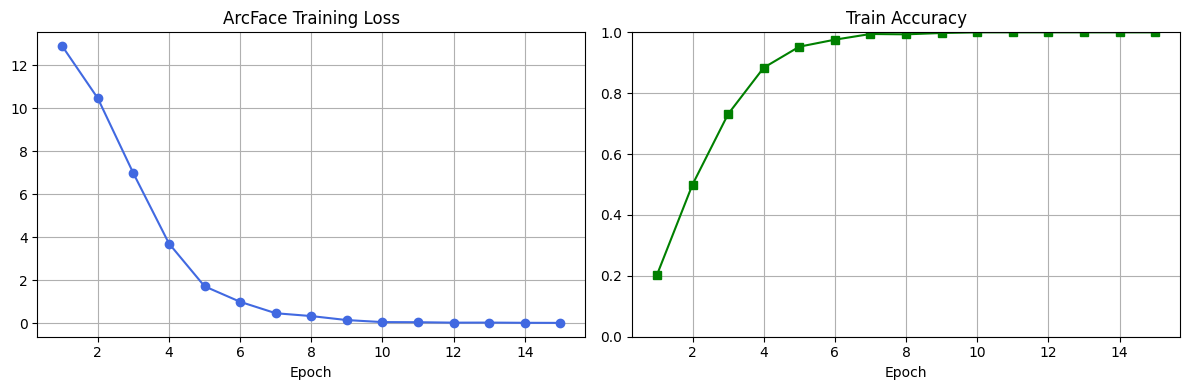

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(range(1,N_EPOCHS+1), history['loss'], marker='o', color='royalblue')
ax1.set_title('ArcFace Training Loss'); ax1.set_xlabel('Epoch'); ax1.grid(True)
ax2.plot(range(1,N_EPOCHS+1), history['acc'],  marker='s', color='green')
ax2.set_title('Train Accuracy'); ax2.set_xlabel('Epoch'); ax2.set_ylim(0,1); ax2.grid(True)
plt.tight_layout(); plt.show()


---
## Section 7 -- Evaluation Pairs

In [9]:
def build_pools(df, writer_set):
    sub = df[df['writer_id'].isin(writer_set)]
    genuine_by_writer, forgery_by_writer = {}, {}
    for wid, grp in sub.groupby('writer_id'):
        g = grp[grp['label']=='genuine']['path'].tolist()
        f = grp[grp['label']=='forgery']['path'].tolist()
        if g: genuine_by_writer[wid] = g
        if f: forgery_by_writer[wid] = f
    return genuine_by_writer, forgery_by_writer

def generate_pairs(df, writer_set, n_pairs=10000, seed=1, neg_mix=0.8):
    genuine_by_writer, forgery_by_writer = build_pools(df, writer_set)
    writers = sorted(genuine_by_writer.keys())
    writers_with_forg = sorted(set(genuine_by_writer) & set(forgery_by_writer))
    rng = np.random.default_rng(seed)
    n_pos = n_pairs // 2; n_neg = n_pairs - n_pos
    n_neg_same = int(round(n_neg * neg_mix)); n_neg_cross = n_neg - n_neg_same
    rows = []
    for _ in range(n_pos):
        w = rng.choice(writers); g = genuine_by_writer[w]
        i, j = rng.choice(len(g), size=2, replace=False)
        rows.append({'path_a':g[i],'path_b':g[j],'label':1,'pair_type':'pos','writer_a':w,'writer_b':w})
    for _ in range(n_neg_same):
        w = rng.choice(writers_with_forg); g = genuine_by_writer[w]; f = forgery_by_writer[w]
        rows.append({'path_a':g[rng.integers(len(g))],'path_b':f[rng.integers(len(f))],
                     'label':0,'pair_type':'neg_same_writer','writer_a':w,'writer_b':w})
    for _ in range(n_neg_cross):
        w1,w2 = rng.choice(writers,size=2,replace=False)
        g1,g2 = genuine_by_writer[w1],genuine_by_writer[w2]
        rows.append({'path_a':g1[rng.integers(len(g1))],'path_b':g2[rng.integers(len(g2))],
                     'label':0,'pair_type':'neg_cross_writer','writer_a':w1,'writer_b':w2})
    return pd.DataFrame(rows).sample(frac=1.0,random_state=seed).reset_index(drop=True)

test_pairs = generate_pairs(df, test_writers, n_pairs=10000, seed=3, neg_mix=0.8)
test_pair_ds     = SiamesePairDataset(test_pairs, transform=eval_tfm)
test_pair_loader = DataLoader(test_pair_ds, batch_size=BATCH, shuffle=False,
                              num_workers=0, pin_memory=DEVICE.type=='cuda')
print(f'Test pairs: {len(test_pairs):,}')
print(test_pairs['label'].value_counts().to_string())


Test pairs: 10,000
label
0    5000
1    5000


---
## Section 8 -- Metrics

Cosine similarity = dot product of L2-normalised embeddings (-1 to 1, higher = more similar).
A well-trained model should show a clear gap between positive and negative distributions.


In [10]:
backbone.eval()
all_sims, all_labels = [], []

with torch.no_grad():
    for img_a, img_b, labels in tqdm(test_pair_loader, desc='Extracting embeddings'):
        e1  = F.normalize(backbone(img_a.to(DEVICE)), dim=1)
        e2  = F.normalize(backbone(img_b.to(DEVICE)), dim=1)
        sim = (e1 * e2).sum(dim=1).cpu().numpy()
        all_sims.append(sim)
        all_labels.append(labels.numpy())

similarity = np.concatenate(all_sims)
y_true     = np.concatenate(all_labels).astype(int)
pos_mean   = similarity[y_true==1].mean()
neg_mean   = similarity[y_true==0].mean()
print(f'Cosine sim (pos): {pos_mean:.4f}')
print(f'Cosine sim (neg): {neg_mean:.4f}')
print(f'Gap             : {pos_mean - neg_mean:.4f}  (larger = better)')


Extracting embeddings:   0%|          | 0/313 [00:00<?, ?it/s]

Cosine sim (pos): 0.8341
Cosine sim (neg): 0.3907
Gap             : 0.4434  (larger = better)


In [11]:
results = compute_metrics(y_true, similarity)

print('\n=== ArcFace v2 Test Metrics (CEDAR) ===')
for k, v in results.items():
    print(f'  {k:<20s}: {v:.4f}')



=== ArcFace v2 Test Metrics (CEDAR) ===
  auc                 : 0.9320
  eer                 : 0.1374
  eer_threshold       : 0.7131
  far                 : 0.1374
  frr                 : 0.1374
  accuracy            : 0.8626
  used_threshold      : 0.7131


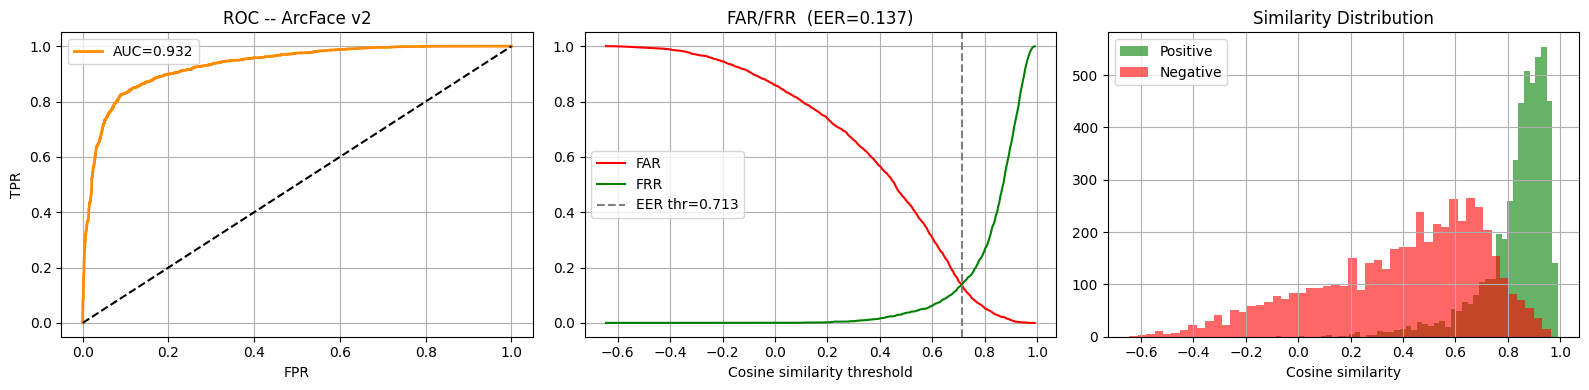

In [12]:
fpr, tpr, _ = sk_metrics.roc_curve(y_true, similarity)
thresholds = np.linspace(similarity.min(), similarity.max(), 400)
far_arr, frr_arr = [], []
for t in thresholds:
    preds = (similarity >= t).astype(int)
    tp = int(((preds==1)&(y_true==1)).sum())
    fp = int(((preds==1)&(y_true==0)).sum())
    fn = int(((preds==0)&(y_true==1)).sum())
    tn = int(((preds==0)&(y_true==0)).sum())
    far_arr.append(fp/(fp+tn) if (fp+tn)>0 else 0.0)
    frr_arr.append(fn/(fn+tp) if (fn+tp)>0 else 0.0)
far_arr = np.array(far_arr); frr_arr = np.array(frr_arr)
eer_thresh = results['eer_threshold']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f"AUC={results['auc']:.3f}")
axes[0].plot([0,1],[0,1],'k--')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC -- ArcFace v2'); axes[0].legend(); axes[0].grid(True)
axes[1].plot(thresholds, far_arr, label='FAR', color='red')
axes[1].plot(thresholds, frr_arr, label='FRR', color='green')
axes[1].axvline(eer_thresh, linestyle='--', color='gray', label=f'EER thr={eer_thresh:.3f}')
axes[1].set_xlabel('Cosine similarity threshold')
axes[1].set_title(f"FAR/FRR  (EER={results['eer']:.3f})")
axes[1].legend(); axes[1].grid(True)
axes[2].hist(similarity[y_true==1], bins=50, alpha=0.6, color='green', label='Positive')
axes[2].hist(similarity[y_true==0], bins=50, alpha=0.6, color='red',   label='Negative')
axes[2].set_xlabel('Cosine similarity'); axes[2].set_title('Similarity Distribution')
axes[2].legend(); axes[2].grid(True)
plt.tight_layout(); plt.show()


---
## Section 9 -- Embedding Space (PCA)

PCA embeddings:   0%|          | 0/7 [00:00<?, ?it/s]

PCA explained variance: 46.87%


/tmp/ipykernel_1026/4259827060.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(test_writers))


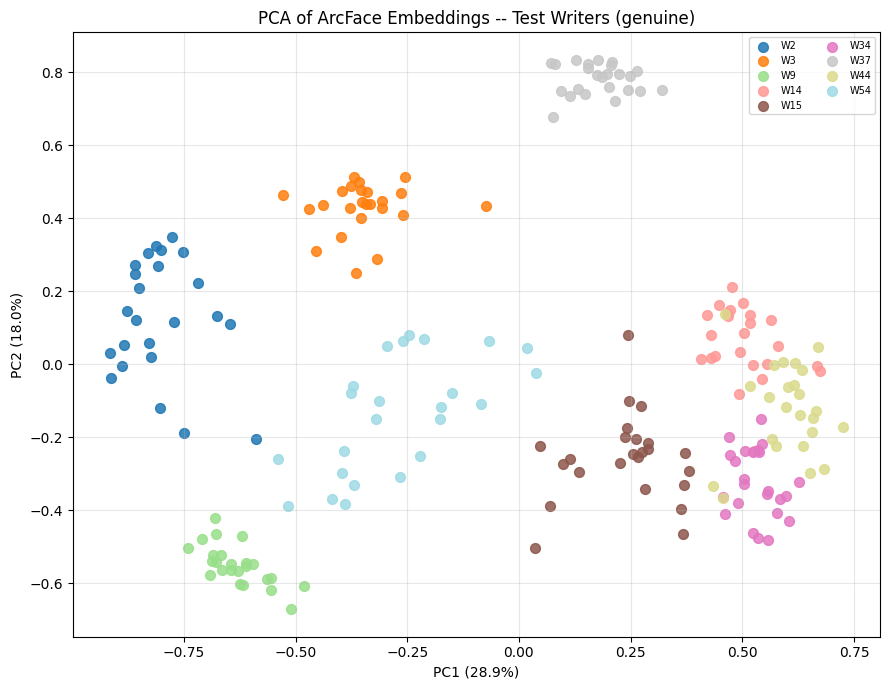

In [13]:
test_writer_to_class = {wid: idx for idx, wid in enumerate(sorted(test_writers))}
test_cls_ds = SignatureClassDataset(
    df, test_writer_to_class, test_writers, label_filter='genuine', transform=eval_tfm
)
test_cls_loader = DataLoader(test_cls_ds, batch_size=BATCH, shuffle=False, num_workers=0)

backbone.eval()
all_embs, all_wids = [], []
with torch.no_grad():
    for imgs, cls_ids in tqdm(test_cls_loader, desc='PCA embeddings'):
        emb = F.normalize(backbone(imgs.to(DEVICE)), dim=1).cpu().numpy()
        all_embs.append(emb)
        all_wids.append(cls_ids.numpy())
all_embs = np.concatenate(all_embs)
all_wids = np.concatenate(all_wids)

pca   = PCA(n_components=2, random_state=SEED)
emb2d = pca.fit_transform(all_embs)
print(f'PCA explained variance: {pca.explained_variance_ratio_.sum():.2%}')

fig, ax = plt.subplots(figsize=(9, 7))
cmap = plt.cm.get_cmap('tab20', len(test_writers))
for i, wid in enumerate(sorted(test_writer_to_class.keys())):
    mask = all_wids == test_writer_to_class[wid]
    ax.scatter(emb2d[mask,0], emb2d[mask,1], color=cmap(i), label=f'W{wid}', s=50, alpha=0.85)
ax.set_title('PCA of ArcFace Embeddings -- Test Writers (genuine)')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.legend(loc='upper right', fontsize=7, ncol=2); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


---
## Section 10 -- Summary

In [14]:
from IPython.display import Markdown, display

rows_md = '\n'.join(f'| {k:<20s} | {v:.4f} |' for k, v in results.items())
gap     = similarity[y_true==1].mean() - similarity[y_true==0].mean()

display(Markdown(f'''
### ArcFace v2 Results -- CEDAR (ResNet18, {N_EPOCHS} epochs)

| Metric               | Value  |
|:---------------------|-------:|
{rows_md}

**Cosine gap** (pos - neg mean): {gap:.4f}  (v1 was 0.0196)

### What changed from v1
| Change | v1 | v2 |
|--------|----|----|  
| Backbone | SmallCNN (2 conv) | ResNet18 (18 layers) |
| Margin | 0.5 | 0.3 |
| Augmentation | None | RandomAffine + noise |
| Scheduler | StepLR | CosineAnnealingLR |
'''))



### ArcFace v2 Results -- CEDAR (ResNet18, 15 epochs)

| Metric               | Value  |
|:---------------------|-------:|
| auc                  | 0.9320 |
| eer                  | 0.1374 |
| eer_threshold        | 0.7131 |
| far                  | 0.1374 |
| frr                  | 0.1374 |
| accuracy             | 0.8626 |
| used_threshold       | 0.7131 |

**Cosine gap** (pos - neg mean): 0.4434  (v1 was 0.0196)

### What changed from v1
| Change | v1 | v2 |
|--------|----|----|  
| Backbone | SmallCNN (2 conv) | ResNet18 (18 layers) |
| Margin | 0.5 | 0.3 |
| Augmentation | None | RandomAffine + noise |
| Scheduler | StepLR | CosineAnnealingLR |
